In [8]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [9]:
results_dir = 'results'
original_dir = 'data/Sketches/Ruled'
final_dir = 'results/final'
comparison_dir = 'results/compare'
files = os.listdir(results_dir)

In [10]:
threshold = 0.75
a = np.log(0.5) / np.log(threshold) 
def transform (x):
    return x ** a

def inv_transform(x):
    return x**(1/a)

In [11]:
def smoothstep(x, n=1):
    for _ in range(n):
        x = 3*x**2 - 2*x**3
    return x

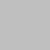

In [12]:
Image.fromarray(np.array(np.ones((50,50,3))*255*.75, dtype='uint8'))

100%|██████████| 214/214 [05:17<00:00,  1.48s/it]


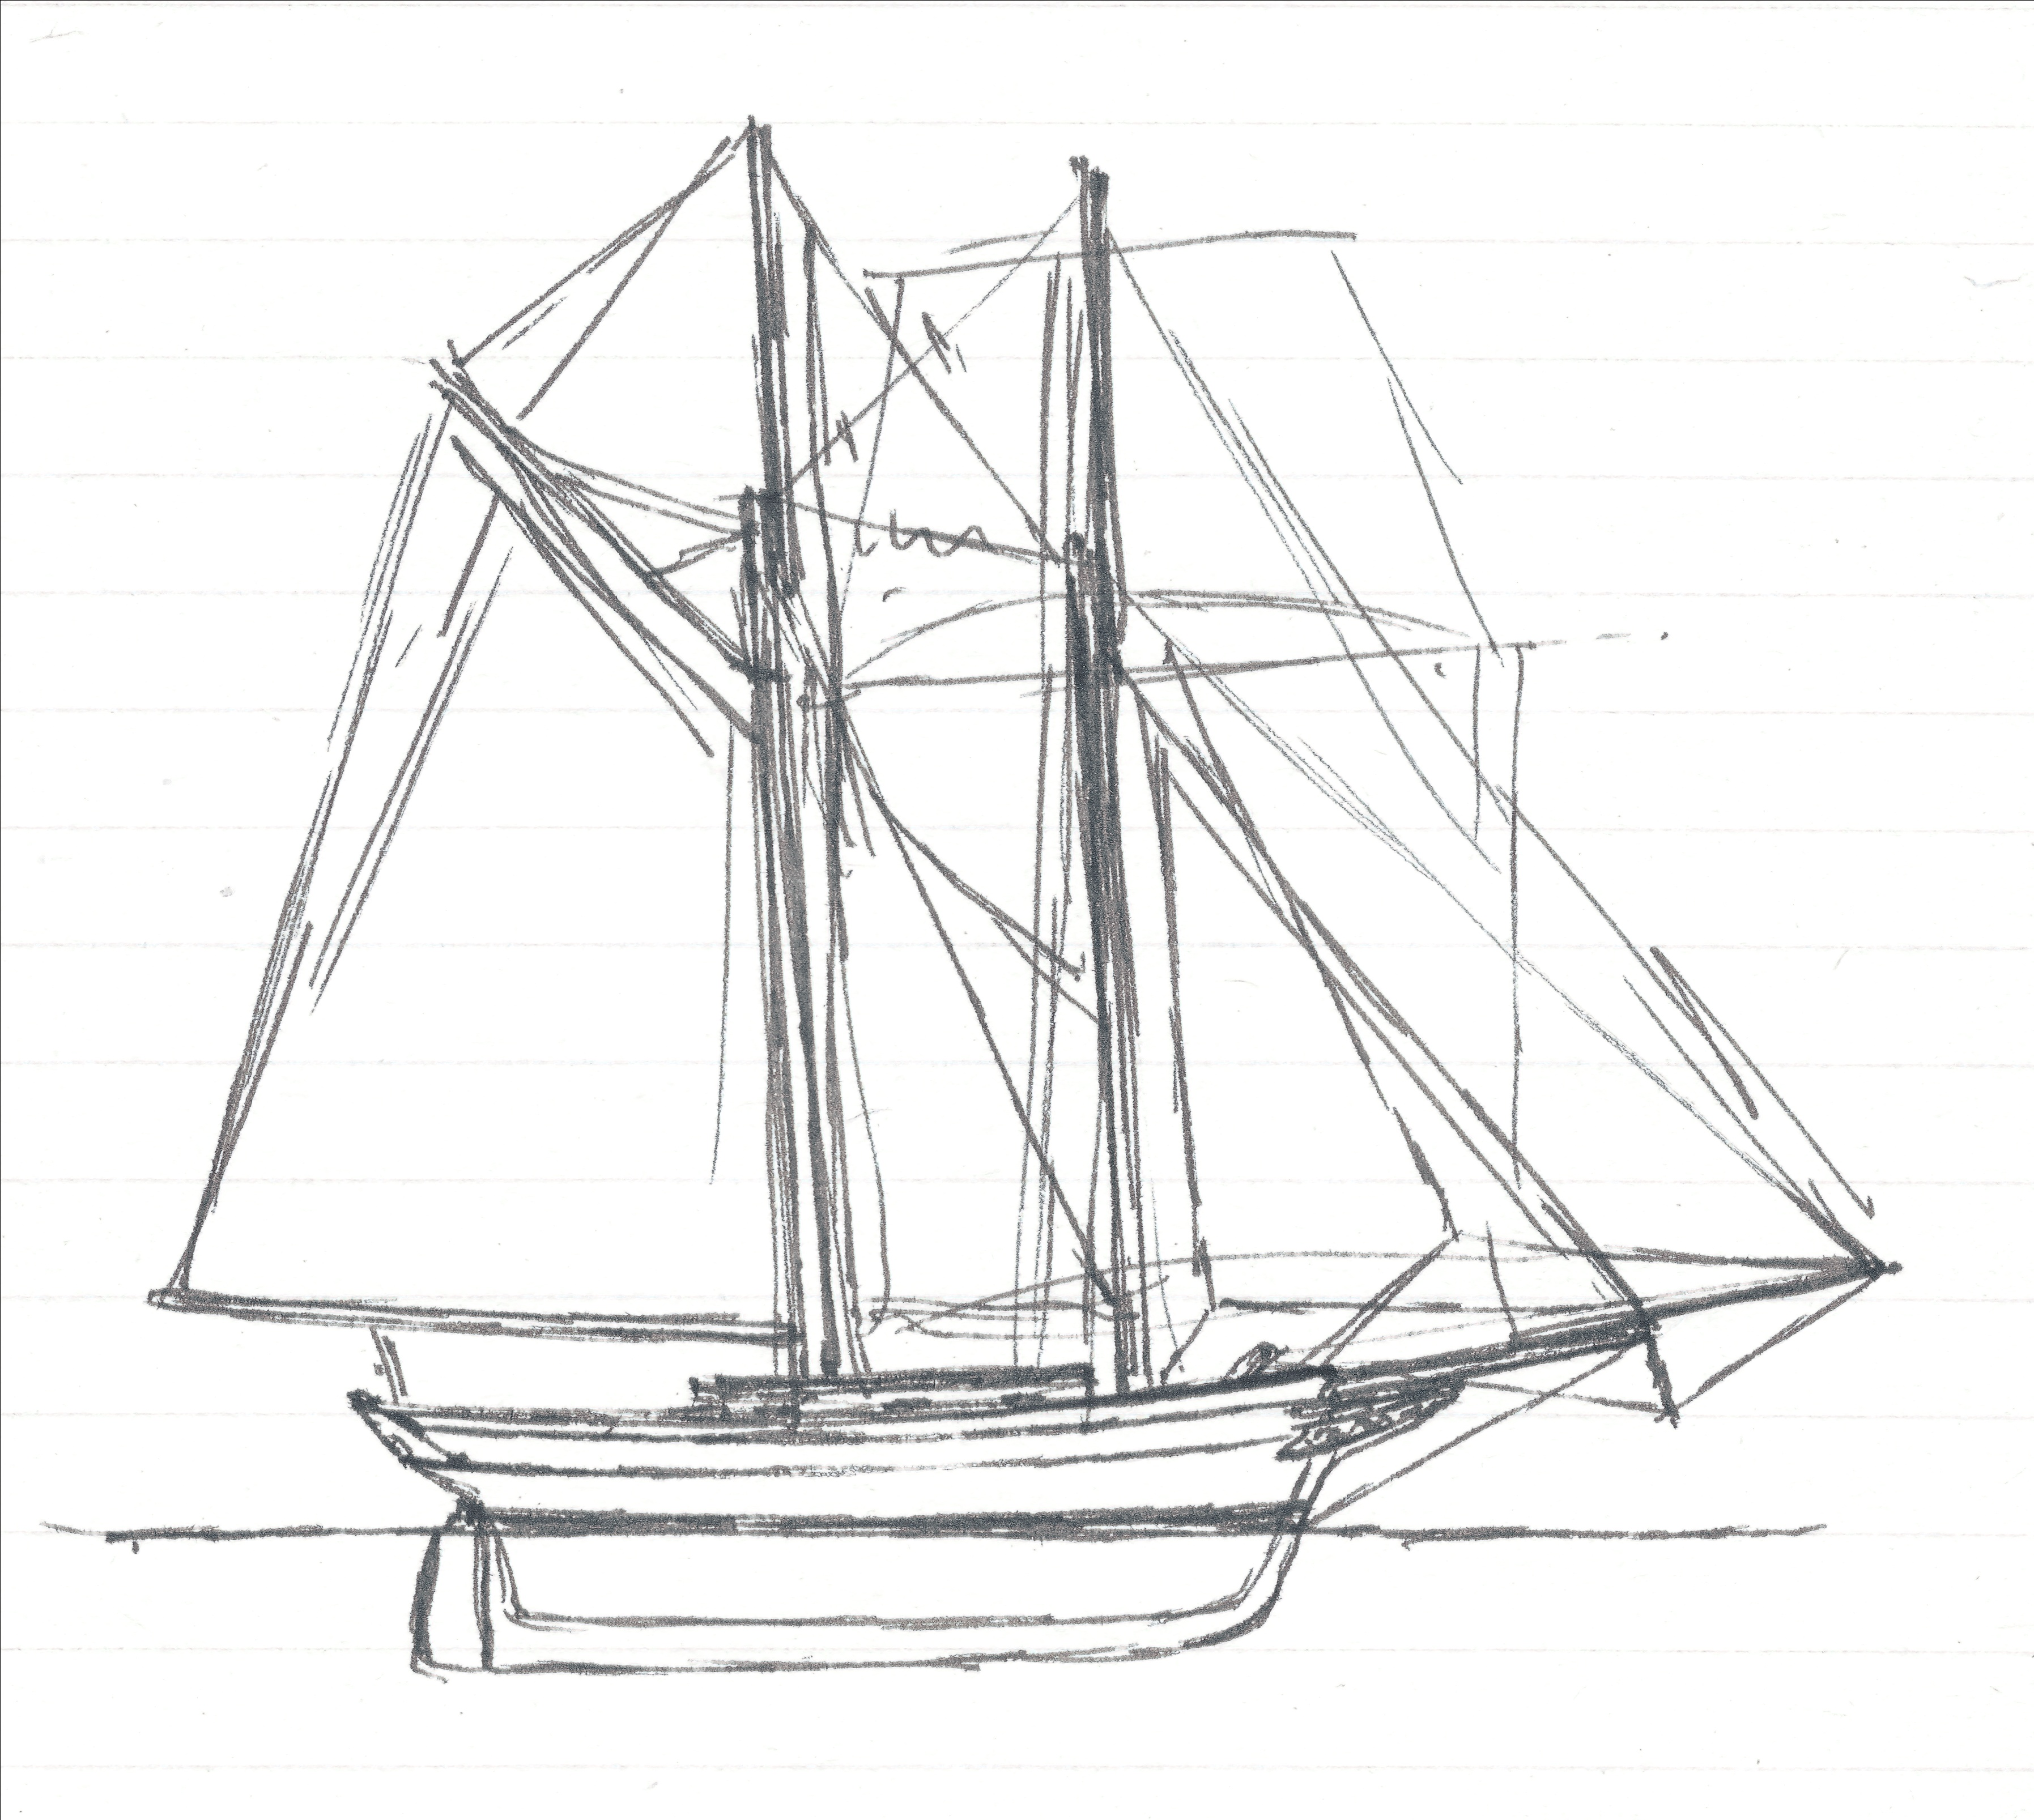

In [13]:
for f in tqdm([i for i in files if i not in ('final','compare')]):
    image = Image.open(os.path.join(results_dir,f))
    i = np.array(image)/255
    j1 = inv_transform(smoothstep(transform(i), 1))
    j2 = inv_transform(smoothstep(transform(i), 2))
    j = (j1+j2)/2
    result = Image.fromarray(np.array(j*255, dtype='uint8'))
    result.save(os.path.join(final_dir, f))

image

In [4]:
def create_comparison_image(input_img, output_img, target_img=None):
    """Create a side-by-side comparison image.

    Args:
        input_img: The input image (with lines)
        output_img: The neural network output
        target_img: The target/ground truth image (optional, from Unruled)

    Returns:
        If target_img is provided: 5-panel image (input | output | target | output-target diff | input-output diff)
        If target_img is None: 3-panel image (input | output | input-output diff)
    """
    width, height = input_img.size

    # Resize output to match input if different
    if output_img.size != (width, height):
        output_img = output_img.resize((width, height), Image.Resampling.LANCZOS)

    # Compute what the model changed (input vs output difference)
    # This shows what was removed/modified by the model
    # removed_diff = compute_difference_image(input_img, output_img)

    if target_img is not None:
        # 5-panel comparison: input | output | target | output-target diff | input-output diff
        if target_img.size != (width, height):
            target_img = target_img.resize((width, height), Image.Resampling.LANCZOS)

        # Compute error (output vs target difference)
        error_diff = compute_difference_image(output_img, target_img)

        comparison = Image.new('RGB', (width * 5, height))
        comparison.paste(input_img, (0, 0))
        comparison.paste(output_img, (width, 0))
        comparison.paste(target_img, (width * 2, 0))
        comparison.paste(error_diff, (width * 3, 0))
        comparison.paste(removed_diff, (width * 4, 0))
    else:
        # 3-panel comparison: input | output | input-output diff
        comparison = Image.new('RGB', (width * 2, height))
        comparison.paste(input_img, (0, 0))
        comparison.paste(output_img, (width, 0))
        # comparison.paste(removed_diff, (width * 2, 0))

    return comparison

In [6]:
for f in tqdm([i for i in files if i not in ('final','compare')]):
    original = Image.open(os.path.join(original_dir,f))
    final = Image.open(os.path.join(final_dir,f))
    c = create_comparison_image(original,final)
    c.save(os.path.join(comparison_dir,f))

100%|███████████████████████████████████████████████████████████████████████████████| 427/427 [01:19<00:00,  5.36it/s]
